# 01_03 - Exploratory Data Analysis

Full EDA on the cleaned, joined dataset: variable distributions, outliers, trend, and seasonality (annual, weekly, daily), the holiday effect, and the relationship between consumption and weather. Everything runs off `data/interim/fsa_hourly_master.parquet`, so no rebuilding from the raw files is needed here.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

import pandas as pd
import matplotlib.pyplot as plt
from common.eda import plot_distribution, plot_boxplot, iqr_outlier_summary, average_profile, plot_average_profile, plot_time_series

DATA_PATH = Path.cwd().parents[1] / "data" / "interim" / "fsa_hourly_master.parquet"
df = pd.read_parquet(DATA_PATH)

print("shape:", df.shape)
df.head()

shape: (262944, 47)


,FSA,timestamp_local,TOTAL_CONSUMPTION,PREMISE_COUNT,year,quarter,month,week_of_year,day_of_year,day_of_month,...,month_sin,month_cos,Temp (°C),Dew Point Temp (°C),Rel Hum (%),Precip. Amount (mm),Wind Dir (10s deg),Wind Spd (km/h),Visibility (km),Stn Press (kPa)
0,M5S,2021-01-01 00:00:00,4186.2,5927,2021,1,1,53,1,1,...,0.0,1.0,-0.9,-5.8,69.0,0.0,NaN,NaN,NaN,101.67
1,M5S,2021-01-01 01:00:00,3868.8,5927,2021,1,1,53,1,1,...,0.0,1.0,-0.8,-5.3,71.0,0.0,NaN,NaN,NaN,101.66
2,M5S,2021-01-01 02:00:00,3652.6,5927,2021,1,1,53,1,1,...,0.0,1.0,-0.9,-5.9,69.0,0.0,NaN,NaN,NaN,101.69
3,M5S,2021-01-01 03:00:00,3538.7,5927,2021,1,1,53,1,1,...,0.0,1.0,-0.8,-4.9,74.0,0.0,NaN,NaN,NaN,101.77
4,M5S,2021-01-01 04:00:00,3417.8,5927,2021,1,1,53,1,1,...,0.0,1.0,-0.3,-4.3,75.0,0.0,NaN,NaN,NaN,101.75


## 1. Distributions

### 1.1 Consumption

`TOTAL_CONSUMPTION` is the target variable, so its shape matters most: how skewed it is, relevant for a log-transform decision made later, and how much the six FSAs differ in scale from each other.

In [2]:
df["TOTAL_CONSUMPTION"].describe()

count    262944.000000
mean       8792.717022
std        4312.827798
min        1377.700000
25%        5224.900000
50%        8111.400000
75%       11544.000000
max       33712.200000
Name: TOTAL_CONSUMPTION, dtype: float64

In [3]:
df.groupby("FSA")["TOTAL_CONSUMPTION"].describe()

,count,mean,std,min,25%,50%,75%,max
FSA,,,,,,,,
L4T,43824.0,11617.975148,3441.406039,5864.4,9175.225,11179.00,13218.025,27796.6
M5R,43824.0,7662.036624,2019.435360,3721.5,6260.275,7461.00,8932.850,16999.0
M5S,43824.0,4108.749952,986.417349,2060.4,3421.000,4044.75,4756.025,7622.4
M6G,43824.0,11488.117506,3177.874939,4954.9,9236.400,11243.00,13509.250,27460.1
M9R,43824.0,5542.009675,1899.714503,1377.7,4222.200,5211.95,6397.625,16243.6
M9W,43824.0,12337.413226,4405.017340,4361.1,8946.875,11916.35,15273.350,33712.2


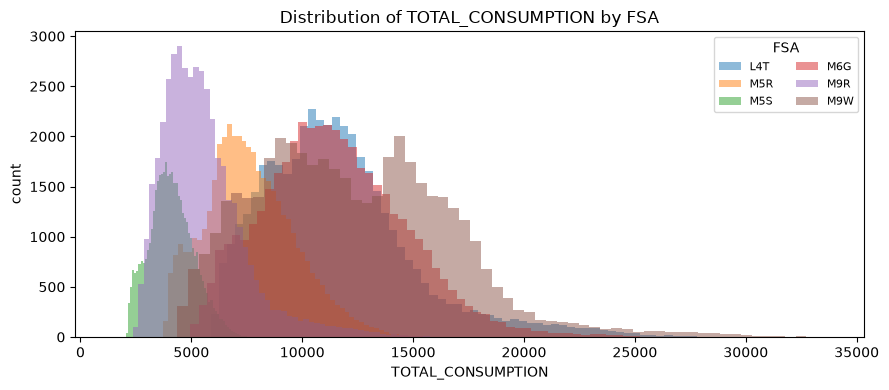

In [4]:
plot_distribution(df, "TOTAL_CONSUMPTION", by="FSA")
plt.show()

Six overlapping histograms sit on the same x-axis, ranging from M5S clustered near the low end (about 2,000-7,600) to M9W spread out toward the high end (about 4,300-33,700). The FSAs do not share a common scale: each has its own typical consumption level tied to how many premises it has (`PREMISE_COUNT`), so `TOTAL_CONSUMPTION` alone mixes "how big is this FSA" with "how much is being consumed relative to its own size." This is worth keeping in mind for modeling: the pooled model needs `fsa` as a categorical feature specifically because a value like 8,000 kWh means something very different in M5S than in L4T.

The overlaid histogram above stacks all six FSAs on the same axes, which makes it hard to see any one FSA's actual shape once the biggest ones dominate the scale. Each FSA is split into its own panel below, one row of the grid per pair, to make the individual shapes clearer.

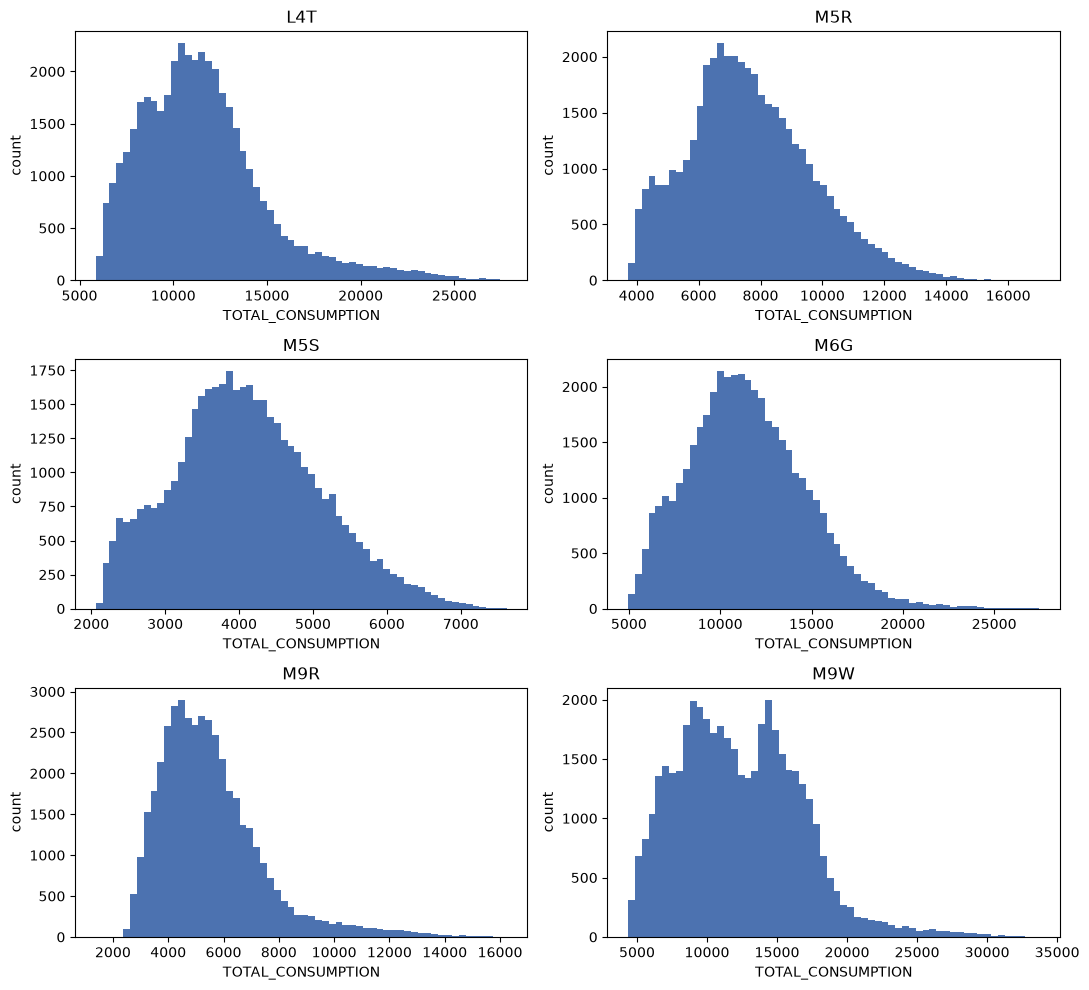

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(11, 10))
for ax, (fsa, group) in zip(axes.flat, df.groupby("FSA")):
    ax.hist(group["TOTAL_CONSUMPTION"], bins=60, color="#4C72B0")
    ax.set_title(fsa)
    ax.set_xlabel("TOTAL_CONSUMPTION")
    ax.set_ylabel("count")
fig.tight_layout()
plt.show()

Each FSA's own distribution appears on its own scale. Every FSA is right-skewed in the same way: a bulk of hours sit around a typical, moderate consumption level, with a long tail stretching toward high values. This is consistent with what a demand series usually looks like: most hours are unremarkable, but heating and cooling extremes push a minority of hours much higher, never much lower. This right-skew is exactly what a log-transform is meant to address later.

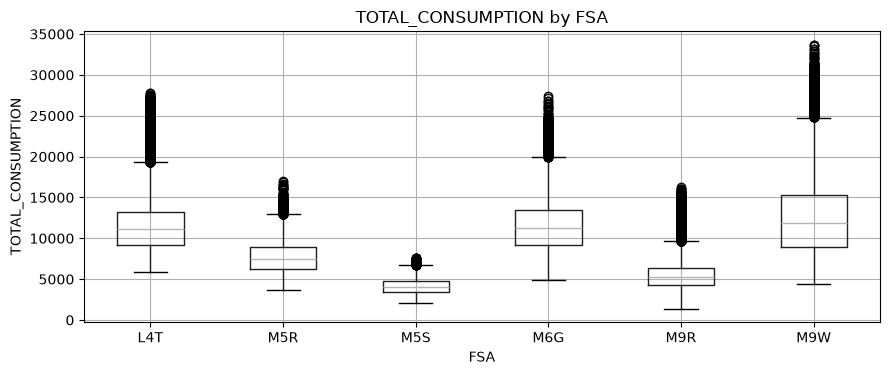

In [6]:
plot_boxplot(df, "TOTAL_CONSUMPTION", by="FSA")
plt.show()

The median, IQR box, and whiskers appear per FSA, with individual points beyond the whiskers marked as candidate outliers. The box heights (IQR) scale roughly with each FSA's overall level: bigger FSAs do not just have a higher median, their day-to-day swings are proportionally larger too. All FSAs show points above the upper whisker but essentially none below it, matching the right-skew from the histograms: high-consumption spikes happen, unusually low spikes basically do not. The exact counts behind these outlier points are quantified next with the IQR rule.

### 1.2 Premise count

Checking whether `PREMISE_COUNT` is essentially fixed per FSA or actually varies over time - that affects how useful it can be as a predictor.

In [7]:
df.groupby("FSA")["PREMISE_COUNT"].agg(["min", "max", "nunique"])

,min,max,nunique
FSA,,,
L4T,8428,8653,126
M5R,8695,9984,175
M5S,5803,6224,84
M6G,11449,12120,335
M9R,5849,6066,162
M9W,9157,11291,528


Reading that table: if `PREMISE_COUNT` were fixed per FSA, `min` and `max` would be identical and `nunique` would be 1 (only one distinct value ever appears). Instead, `min` and `max` differ for every FSA (for example M5S goes from 5,803 to 6,224), and `nunique` shows dozens to hundreds of distinct values, so it is not a single fixed number. The plot below shows what that variation actually looks like over time.

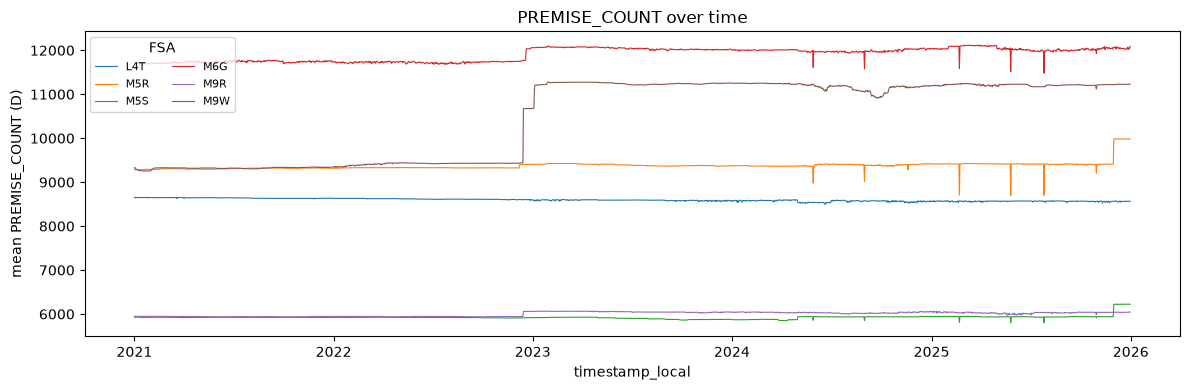

In [8]:
plot_time_series(df, "PREMISE_COUNT", group_by="FSA", freq="D")
plt.show()

Each line is mostly flat, with occasional sharp step changes rather than a smooth, continuous trend, most visibly M9W stepping up around late 2022 and M6G/M5R stepping down around mid-2025.

These steps are not organic customer growth, they come from how `PREMISE_COUNT` is built. It is the sum of premises across every `CUSTOMER_TYPE`×`PRICE_PLAN` combination reported that hour, and the set of combinations reported is not fixed over time. Checking the raw file directly confirms this: on 2022-12-15, a brand new combination (`SGS <50kW - Tiered`) starts appearing for both M9W and M9R on that exact same date. The total jumps because a new category is now being counted, not because thousands of new premises appeared overnight. `PREMISE_COUNT` should be read as premises under all currently-reported billing plans, which shifts in discrete steps whenever the plan mix reported for an FSA changes, not as a smooth measure of population or building growth.

### 1.3 Weather variables

`Temp`, `Dew Point Temp`, `Rel Hum`, and `Stn Press` are reported by both stations, so their distributions can be looked at directly. `Precip`, `Wind Dir`, `Wind Spd`, and `Visibility` are each only populated by the station that measures them, dropping the nulls before plotting each one avoids an empty half of the sample distorting the picture.

Each panel below is a histogram: the x-axis is the value of that variable in its own unit (labeled per panel), and the y-axis is how many of the about 262,944 hourly rows fall into that bin, a count, not a percentage. A tall bar around 0 mm in the `Precip. Amount` panel, for example, just means most hours have no measurable precipitation, not that anything is wrong.

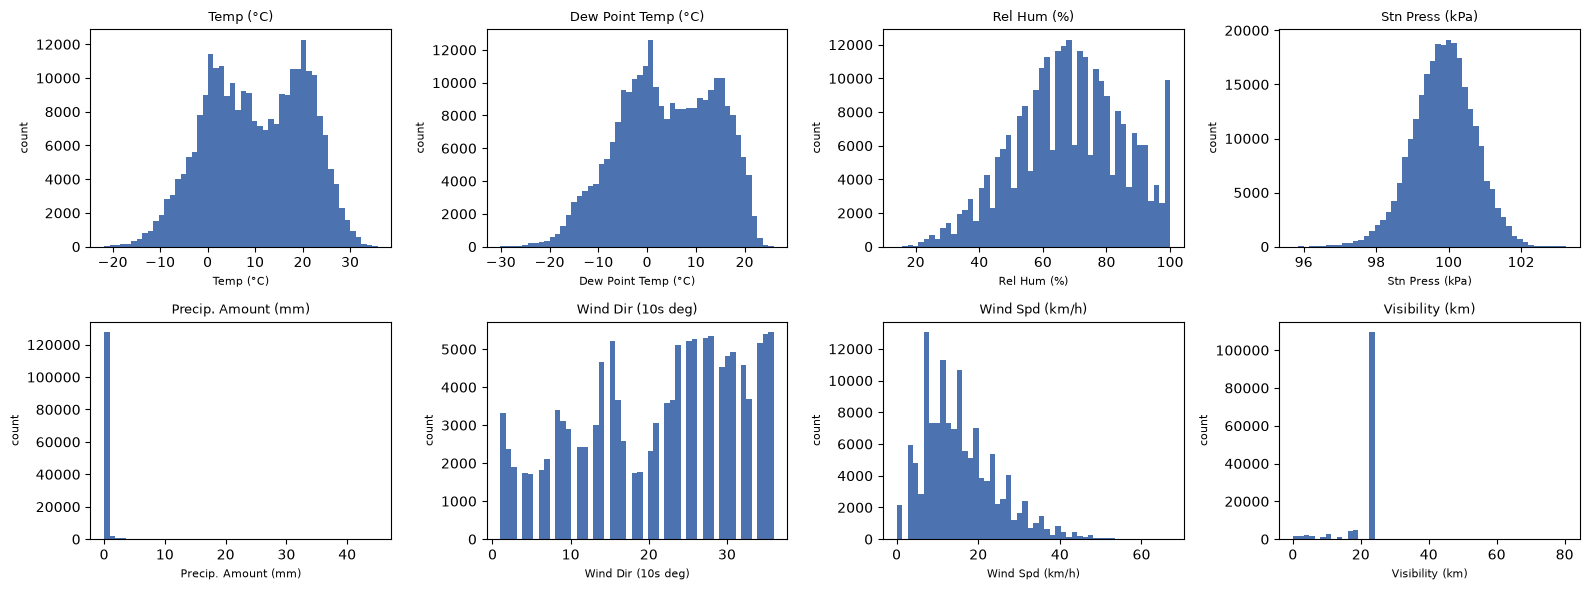

In [9]:
weather_columns = [
    "Temp (°C)", "Dew Point Temp (°C)", "Rel Hum (%)", "Stn Press (kPa)",
    "Precip. Amount (mm)", "Wind Dir (10s deg)", "Wind Spd (km/h)", "Visibility (km)",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, weather_columns):
    ax.hist(df[col].dropna(), bins=50, color="#4C72B0")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("count", fontsize=8)
fig.tight_layout()
plt.show()

`Temp` and `Stn Press` look close to symmetric bell shapes (skew of -0.13 and -0.22 respectively, close to 0, close to symmetric). `Precip. Amount` is heavily zero-inflated: 45.8% of hours have exactly 0 mm, so most of its mass sits in a single spike at zero with a thin tail of rainy hours. `Wind Spd` is the opposite, genuinely calm hours (exactly 0 km/h) are rare, only 0.8% of the time. `Visibility` has an unusual quirk worth flagging: the 25th, 50th, and 75th percentiles are all exactly 24.1 km, meaning more than half of all readings are clustered at that one value, most likely a sensor or reporting ceiling ("visibility ≥ 24.1 km" gets recorded as exactly 24.1 rather than as an unbounded distance) rather than a real physical distribution.

`Visibility` is not a clean continuous measurement the way `Temp` is, a large chunk of its values are a reporting artifact, not a physical difference between calm, sunny hours 24.1 km apart. This is worth remembering if `Visibility` ends up being evaluated as a feature later.

### 1.4 Calendar coverage

`season`, `weekday`, and `hour` should all come out perfectly balanced, since the dataset is a complete hourly grid rather than a sample - confirming that before relying on it later.

In [10]:
df["season"].value_counts()

season
Spring    66240
Summer    66240
Fall      65520
Winter    64944
Name: count, dtype: int64

In [11]:
df["weekday"].value_counts().sort_index()

weekday
0    37584
1    37584
2    37584
3    37440
4    37584
5    37584
6    37584
Name: count, dtype: int64

In [12]:
df["hour"].value_counts().sort_index()

hour
0     10956
1     10956
2     10956
3     10956
4     10956
5     10956
6     10956
7     10956
8     10956
9     10956
10    10956
11    10956
12    10956
13    10956
14    10956
15    10956
16    10956
17    10956
18    10956
19    10956
20    10956
21    10956
22    10956
23    10956
Name: count, dtype: int64

## 2. Outliers

### 2.1 Consumption

Two separate checks: implausible values (zero or negative consumption, which should not happen for an occupied FSA), and statistical outliers via the IQR rule, computed per FSA and per season. A spike that is normal in winter could be an outlier in summer, so pooling seasons together would hide that.

In [13]:
print("rows with TOTAL_CONSUMPTION <= 0:", (df["TOTAL_CONSUMPTION"] <= 0).sum())
print("min value:", df["TOTAL_CONSUMPTION"].min())

rows with TOTAL_CONSUMPTION <= 0: 0
min value: 1377.7


In [14]:
iqr_outlier_summary(df, "TOTAL_CONSUMPTION", group_by="FSA")

,FSA,lower_bound,upper_bound,n_below,n_above,pct_outliers
0,L4T,3111.0250,19282.2250,0,1760,4.02
1,M5R,2251.4125,12941.7125,0,479,1.09
2,M5S,1418.4625,6758.5625,0,248,0.57
3,M6G,2827.1250,19918.5250,0,501,1.14
4,M9R,959.0625,9660.7625,0,1842,4.20
5,M9W,-542.8375,24763.0625,0,549,1.25


In [15]:
df["FSA_season"] = df["FSA"] + " - " + df["season"]
iqr_outlier_summary(df, "TOTAL_CONSUMPTION", group_by="FSA_season").sort_values("pct_outliers", ascending=False)

,FSA_season,lower_bound,upper_bound,n_below,n_above,pct_outliers
16,M9R - Fall,997.3125,8572.4125,0,135,1.24
0,L4T - Fall,2648.1750,17639.7750,0,126,1.15
17,M9R - Spring,1628.8875,7908.7875,0,106,0.96
5,M5R - Spring,3038.0250,10687.8250,0,106,0.96
6,M5R - Summer,1757.4000,14092.0000,0,97,0.88
14,M6G - Summer,1292.0250,23181.8250,0,96,0.87
1,L4T - Spring,3859.3750,16426.9750,0,92,0.83
22,M9W - Summer,-1912.8500,29599.9500,0,79,0.72
18,M9R - Summer,-1077.1625,14260.5375,0,71,0.64
4,M5R - Fall,2377.6500,10928.6500,0,70,0.64


### 2.2 Weather

This section checks for physically implausible values rather than statistical outliers, since real weather is genuinely extreme sometimes (a heat wave or a cold snap is not an "outlier" to remove). The useful check is whether any values fall outside what is physically possible.

Five checks cover the variables that actually have a hard physical floor or ceiling: relative humidity cannot exceed 100%, precipitation, wind speed, and visibility cannot be negative, and pressure cannot be zero or negative. `Temp` and `Dew Point Temp` are deliberately left out of this check, negative values there are completely normal in an Ontario winter (for example -22°C shows up in the data below), so a "< 0" rule would flag thousands of perfectly valid readings. Temperature does not have a physically implausible range worth checking here the way the other five do.

In [16]:
pd.Series({
    "Rel Hum (%) > 100": (df["Rel Hum (%)"] > 100).sum(),
    "Precip. Amount (mm) < 0": (df["Precip. Amount (mm)"] < 0).sum(),
    "Wind Spd (km/h) < 0": (df["Wind Spd (km/h)"] < 0).sum(),
    "Visibility (km) < 0": (df["Visibility (km)"] < 0).sum(),
    "Stn Press (kPa) <= 0": (df["Stn Press (kPa)"] <= 0).sum(),
}, name="implausible_value_count")

Rel Hum (%) > 100          0
Precip. Amount (mm) < 0    0
Wind Spd (km/h) < 0        0
Visibility (km) < 0        0
Stn Press (kPa) <= 0       0
Name: implausible_value_count, dtype: int64

## 3. Trend

Daily-average consumption over the full 2021-2025 span, one line per FSA - long-term direction and any visible anomalies (data gaps, sudden level shifts) should show up here.

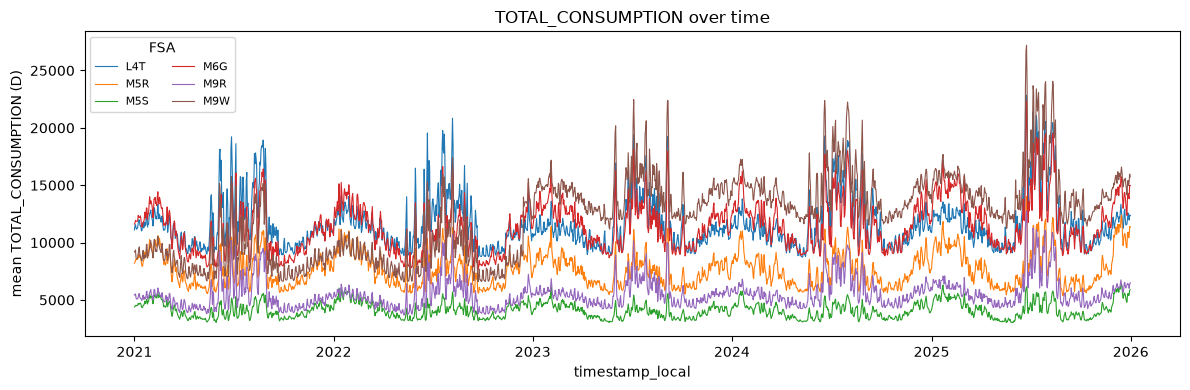

In [17]:
plot_time_series(df, "TOTAL_CONSUMPTION", group_by="FSA", freq="D")
plt.show()

Five years of daily-average consumption appear above, one line per FSA, each oscillating in a regular wave. That wave is the annual seasonal cycle (winter and summer peaks, spring and fall troughs) repeating five times, a first visual confirmation of the seasonality quantified in Section 4. The six FSAs stay in their own relative bands throughout (M9W consistently highest, M5S consistently lowest) without crossing over or drifting apart, a reasonable sign that there is no obvious long-term upward or downward trend distinct from the seasonal pattern, and no visible large data gaps or level shifts left over from cleaning.

## 4. Seasonality

Three levels, from the widest cycle to the narrowest: month of year (heating/cooling load), day of week (weekday vs weekend), and hour of day (morning/evening peaks).

**Important about all three plots below:** each point is an average pooled across all 5 years of history (2021-2025), not any single year or week. "Month = 7" in the plot below means "the average of every July hour across 2021, 2022, 2023, 2024, and 2025 combined" - same idea for "weekday = 0" (every Monday across all 5 years) and later for "hour = 18" (every 6pm across the whole dataset). This is intentional: it isolates the typical/repeating seasonal shape, separately from the year-over-year trend already looked at in Section 3.

### 4.1 Monthly (annual cycle)

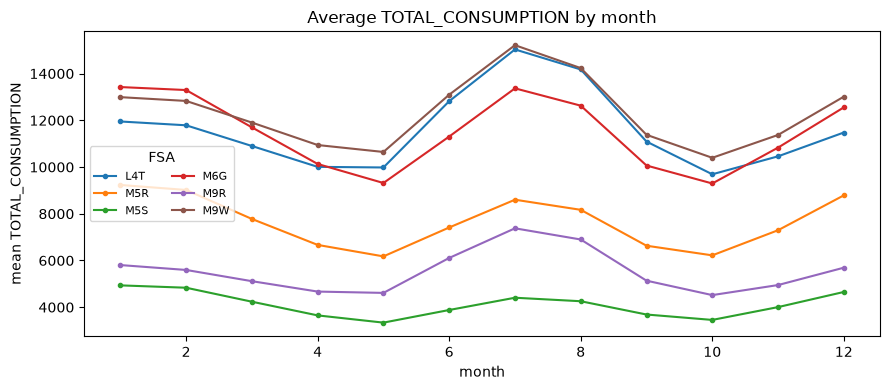

In [18]:
plot_average_profile(df, "TOTAL_CONSUMPTION", period_col="month", group_by="FSA")
plt.show()

Average consumption by calendar month, pooled across all 5 years, appears above, one line per FSA. There is a clear annual "U" shape: highest in July (about 10,666 pooled across FSAs), still elevated in December and January (about 9,360-9,720), and lowest in the shoulder months May and October (about 7,300-7,345). All six FSAs trace the same shape in parallel, just at different overall heights, so the seasonal pattern itself does not depend on which FSA it is, only the scale does. This lines up with the asymmetric valley already found against actual temperature in Section 6, a steeper rise into summer than the decline out of winter.

### 4.2 Weekday vs weekend

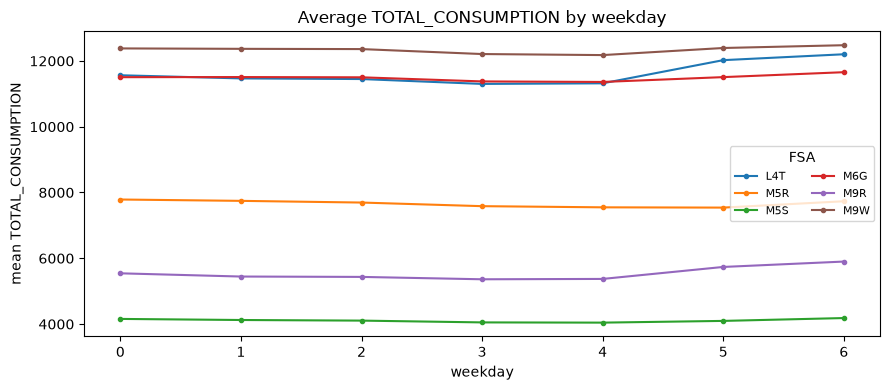

In [19]:
plot_average_profile(df, "TOTAL_CONSUMPTION", period_col="weekday", group_by="FSA")
plt.show()

Average consumption by day of week, pooled across all 5 years, appears above. The effect is small and, mildly counter to the usual assumption, weekends come out *higher* than most workdays (pooled across FSAs: workdays sit around 8,637-8,823, versus 8,883-9,025 on the two weekend days). This is consistent with these being largely residential FSAs, people spend more time at home on weekends, which raises consumption rather than lowering it the way it would in a commercial or office-heavy area. The swing is modest either way, roughly 4% top to bottom, much smaller than the monthly seasonal swing.

### 4.3 Hour of day

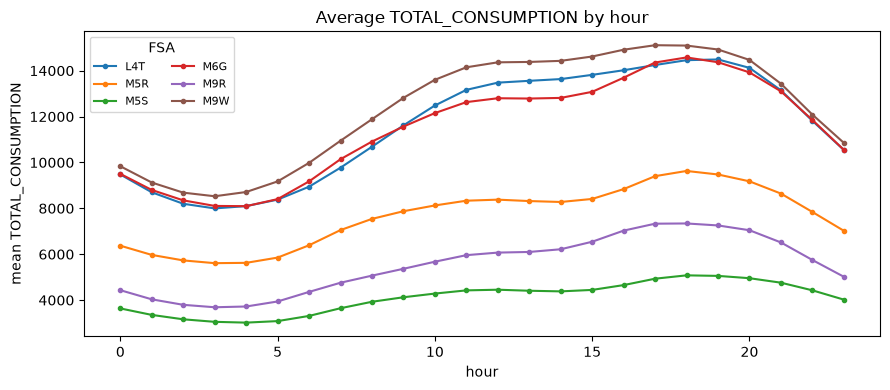

In [20]:
plot_average_profile(df, "TOTAL_CONSUMPTION", period_col="hour", group_by="FSA")
plt.show()

Average consumption by hour of day, pooled across all 5 years, appears above, one line per FSA. There is a single broad evening peak, not two separate morning and evening peaks: a minimum around 3-4am (about 6,160-6,210 pooled), rising steadily through the day to a peak around 6pm (about 11,030 pooled), then declining back overnight. All six FSAs share this exact same hourly shape, again just at different heights. Hour of day looks like a strong, consistent driver of consumption regardless of FSA, which matches it showing up as one of the stronger correlations with the target in Section 7.

### 4.4 Hour of day, weekday vs weekend

Checking whether the hourly shape itself differs between workdays and weekends, pooled across all FSAs to keep it readable as one comparison.

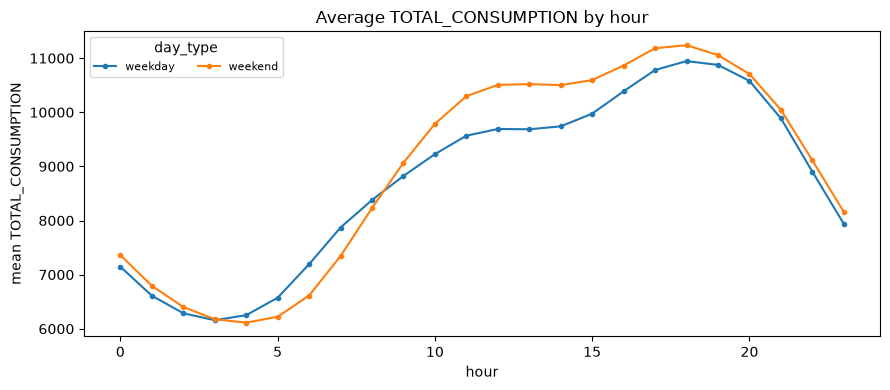

In [21]:
df["day_type"] = df["is_weekend"].map({0: "weekday", 1: "weekend"})
plot_average_profile(df, "TOTAL_CONSUMPTION", period_col="hour", group_by="day_type")
plt.show()

Two hourly curves appear above with the same general single-peak shape, but not identical. There is no double commute peak on weekdays, both day types still just have one broad evening peak. The real difference is in the middle of the day: weekends run noticeably higher from about 9am to 3pm (for example 11am: 10,298 weekend versus 9,567 weekday), while weekdays run slightly higher very early in the morning (for example 6am: 7,192 weekday versus 6,613 weekend). This pattern fits a residential area well, people leave for work on weekday mornings (a small early bump, then consumption drops as homes empty out), while on weekends people stay home through the whole midday. By evening the two lines converge and both peak around the same hour.

## 5. Holiday effect

Comparing average consumption on public holidays against regular days.

In [22]:
df.groupby("is_public_holiday")["TOTAL_CONSUMPTION"].agg(["mean", "median", "std"])

,mean,median,std
is_public_holiday,,,
0,8797.360439,8111.05,4321.488175
1,8624.322095,8121.55,3982.689205


## 6. Consumption vs temperature

Electricity demand is expected to be non-linear in temperature: heating drives it up in the cold, cooling drives it up in the heat, with a minimum somewhere in mild weather in between. The shape does not have to be symmetric, though, so the actual curve is checked directly rather than assuming one.

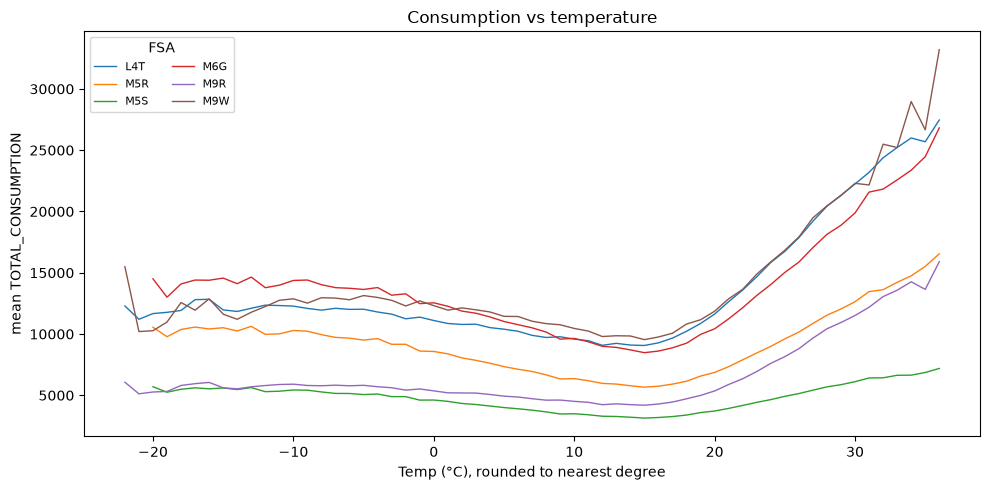

In [23]:
df["temp_bin"] = df["Temp (°C)"].round()

fig, ax = plt.subplots(figsize=(10, 5))
for fsa, group in df.groupby("FSA"):
    profile = group.groupby("temp_bin")["TOTAL_CONSUMPTION"].mean()
    ax.plot(profile.index, profile.values, label=fsa, linewidth=1)
ax.set_xlabel("Temp (°C), rounded to nearest degree")
ax.set_ylabel("mean TOTAL_CONSUMPTION")
ax.set_title("Consumption vs temperature")
ax.legend(title="FSA", ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

The curve does have a minimum in the middle (around 15°C), so there is a mild "valley" shape overall, but it is clearly **not symmetric**. On the cold side, consumption declines fairly gradually from -22°C down to the minimum. On the hot side, it rises much more sharply: it roughly triples between 15°C and 36°C, and the slope keeps getting steeper past about 27-28°C rather than leveling off. The right (hot) half of the curve looks close to exponential growth, while the left (cold) half looks closer to a gentler, more linear decline, an asymmetric valley rather than a clean, symmetric U.

## 7. Preliminary correlation

A first look at how the numeric variables relate to `TOTAL_CONSUMPTION`, not a feature-selection decision, which needs a proper pass over train-only data per fold, just an early read on what is likely to matter.

Two correlation measures are shown side by side, because they catch different things: **Pearson** only picks up *linear* relationships, and **Spearman** picks up any *monotonic* relationship (consistently increasing or decreasing, even if curved), a strictly wider net than Pearson's. Neither one can fully capture the temperature relationship from Section 6, though: that curve is not monotonic at all, it goes down and then back up, so both measures understate it. Kendall's tau answers essentially the same question as Spearman (both are rank-based, monotonic-only) but is much more expensive to compute at this size (262,944 rows), so it is skipped here as redundant. The one method that *can* fully capture a non-monotonic relationship like temperature's is feature importance from an actual trained model, such as XGBoost, left for a later step once a model exists to compute it from.

In [24]:
numeric_cols = df.select_dtypes("number").columns.drop(["TOTAL_CONSUMPTION"])

corr_table = pd.DataFrame({
    "pearson": df[numeric_cols].corrwith(df["TOTAL_CONSUMPTION"], method="pearson"),
    "spearman": df[numeric_cols].corrwith(df["TOTAL_CONSUMPTION"], method="spearman"),
})
corr_table.reindex(corr_table["spearman"].abs().sort_values(ascending=False).index)

,pearson,spearman
PREMISE_COUNT,0.664477,0.680069
hour,0.298962,0.300775
hour_sin,-0.309194,-0.292355
hour_cos,-0.198296,-0.204524
is_peak_hour_window,0.171666,0.179508
year,0.144334,0.122493
Wind Spd (km/h),0.111686,0.121575
is_business_hour,0.125695,0.119200
Stn Press (kPa),-0.109630,-0.112602
is_daylight_saving_time,-0.072607,-0.103671


Pearson and Spearman appear side by side above, sorted by Spearman's strength. The two mostly agree on ranking: `PREMISE_COUNT` and the hour-of-day features come out strongest under both. `Temp (°C)` stays weak under both (0.08 Pearson, and similarly weak under Spearman) despite the clear valley shape found in Section 6, confirming the prediction from the intro above: since the relationship goes down then up, it is not monotonic, so even Spearman cannot detect it. This is a concrete example of why "low correlation" here does not mean "not useful for the model," it means these two particular measures are not the right tool for this particular shape.

### 7.1 Actual relationship shapes

Correlation coefficients are a single number - looking at the real curve for each weather variable directly (binned averages, same approach as the temperature plot in Section 6) shows the shape a coefficient alone would hide.

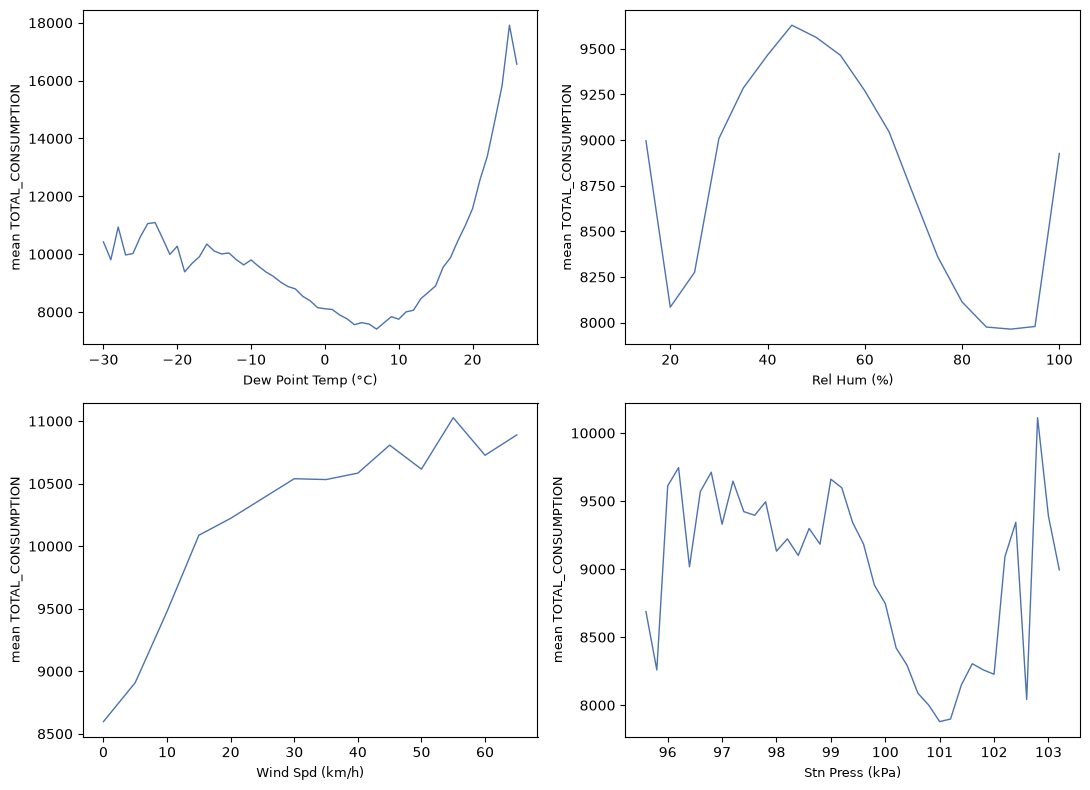

In [25]:
binned_vars = {
    "Dew Point Temp (°C)": 1,
    "Rel Hum (%)": 5,
    "Wind Spd (km/h)": 5,
    "Stn Press (kPa)": 0.2,
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (col, bin_width) in zip(axes.flat, binned_vars.items()):
    bin_col = (df[col] / bin_width).round() * bin_width
    profile = df.groupby(bin_col)["TOTAL_CONSUMPTION"].mean()
    ax.plot(profile.index, profile.values, linewidth=1, color="#4C72B0")
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel("mean TOTAL_CONSUMPTION", fontsize=9)
fig.tight_layout()
plt.show()

Four different shapes appear above, none of them simple straight lines.

- `Dew Point Temp` mirrors `Temp` almost exactly, the same asymmetric valley (declining from cold extremes down to a minimum, then rising sharply toward the warm/humid extreme), which makes physical sense since dew point tracks air temperature closely.
- `Rel Hum` is a hump, not a valley: consumption is *lower* at both very low (about 15-20%) and very high (about 85-90%) humidity, and *higher* around a moderate 40-50%. This is a genuinely non-monotonic shape too, and it is probably not humidity driving consumption directly so much as humidity being a byproduct of the same weather systems, temperature and season, that do drive it.
- `Wind Spd` is the closest of the four to a straight monotonic relationship: consumption rises fairly steadily as wind speed increases, from about 8,600 near calm up to 10,700-11,000 in the windiest bins, though those top bins have few observations, so some of that flattening and noise at the very end is just small-sample variance.
- `Stn Press` is the noisiest and weakest of the four, with only a mild downward drift and no clean shape, the least promising of the four as a standalone predictor.

None of this decides what goes into the model, that step still needs a proper feature-selection pass, but it does show that a single correlation number would have hidden real structure in three of these four variables.

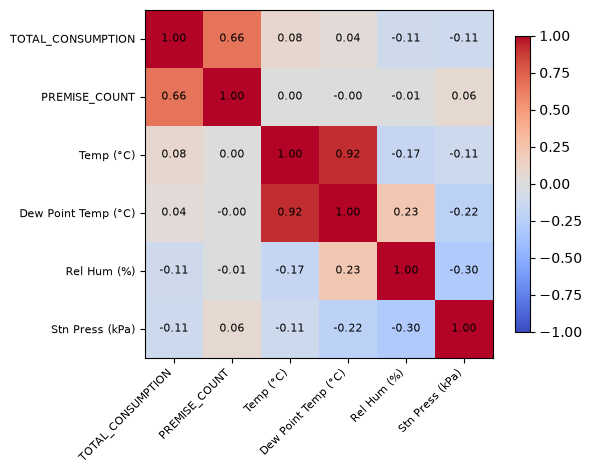

In [26]:
heatmap_cols = ["TOTAL_CONSUMPTION", "PREMISE_COUNT", "Temp (°C)", "Dew Point Temp (°C)", "Rel Hum (%)", "Stn Press (kPa)"]
corr_matrix = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_cols)))
ax.set_xticklabels(heatmap_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(heatmap_cols)))
ax.set_yticklabels(heatmap_cols, fontsize=8)
for i in range(len(heatmap_cols)):
    for j in range(len(heatmap_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()

Pairwise Pearson correlation appears above among `TOTAL_CONSUMPTION`, `PREMISE_COUNT`, and the four shared weather measurements. `Temp` and `Dew Point Temp` are very strongly correlated with each other, as expected since they are physically linked, which means they largely carry the same information, a candidate for dropping one of them later rather than feeding the model two near-duplicate signals. `Rel Hum` correlates negatively with both `Temp` and `Dew Point Temp` in this simple linear view, consistent with the hump-shaped, temperature-driven pattern seen just above. None of the weather variables show a strong direct linear link to `TOTAL_CONSUMPTION` here, reinforcing the same point as the rest of this section: their real relationship to consumption is non-linear, and a linear correlation matrix understates it.